# 03 - Strategy Signals

Construct the 50-day / 200-day moving-average trend-following signal used to decide when the strategy is long vs. in cash.


## Setup


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import data
import signals

prices = data.load_prices()


## Moving averages

A simple moving average (SMA) smooths out day-to-day noise so we can see the underlying trend. The classic "golden cross / death cross" trend signal compares a short-window SMA to a long-window SMA:
- **50-day SMA above 200-day SMA** -> shorter-term trend is above the longer-term trend -> treat as an uptrend -> go long.
- **50-day SMA below 200-day SMA** -> treat as a downtrend/no clear uptrend -> go to cash.

The 200-day SMA needs 200 prior closes to exist, so both averages are `NaN` for the first 199 trading days of each ticker's history -- there's simply not enough data yet.


In [2]:
with_ma = signals.add_moving_averages(prices)
with_ma[with_ma["Ticker"] == "SPY"][["Date", "Close", "SMA_50", "SMA_200"]].tail()


,Date,Close,SMA_50,SMA_200
20985,2026-09-04,770.190002,756.857201,709.868549
20986,2026-09-08,765.960022,757.596602,710.425069
20987,2026-09-09,762.400024,758.024602,710.951142
20988,2026-09-10,757.830017,758.245802,711.504451
20989,2026-09-11,764.289978,758.616401,712.057826


## From signal to position: avoiding lookahead bias

`Signal` is 1 (long) or 0 (cash) based on **today's** closing moving averages. But we can't actually act on today's closing price until the market has already closed -- so if we backtested using `Signal` directly, we'd implicitly be assuming we can trade at a price we couldn't have known yet. That's lookahead bias, and it inflates backtest results in a way that won't hold up in reality.

To avoid it, `Position` is `Signal` shifted forward by one day: the position we hold on day *t* is based on the signal computed from day *t-1*'s close. During the warm-up period (before the 200-day SMA exists), `Position` is set to 0 -- we simply don't have enough information yet to take a stance.


In [3]:
sig = signals.generate_signals(with_ma)
sig[sig["Ticker"] == "SPY"][["Date", "Close", "SMA_50", "SMA_200", "Signal", "Position"]].iloc[195:205]


,Date,Close,SMA_50,SMA_200,Signal,Position
16987,2010-10-12,88.573326,84.114051,NaN,NaN,0.0
16988,2010-10-13,89.262154,84.209393,NaN,NaN,0.0
16989,2010-10-14,88.913948,84.286476,NaN,NaN,0.0
16990,2010-10-15,89.095634,84.369000,NaN,NaN,0.0
16991,2010-10-18,89.534676,84.467232,84.272237,1.0,0.0
16992,2010-10-19,88.361359,84.532962,84.291151,1.0,1.0
16993,2010-10-20,89.224342,84.625138,84.313261,1.0,1.0
16994,2010-10-21,89.421112,84.767631,84.336056,1.0,1.0
16995,2010-10-22,89.587677,84.923544,84.357893,1.0,1.0
16996,2010-10-25,89.852585,85.089574,84.379636,1.0,1.0


## Counting trades

A "trade" happens whenever `Position` changes from the prior day (0 -> 1 is a buy, 1 -> 0 is a sell/exit to cash). Since this is a slow, long-window signal, we expect only a handful of trades per year, not frequent trading.


In [4]:
signals.count_trades(sig)


Ticker
AAPL    15
MSFT    21
NVDA    13
QQQ     17
SPY     15
Name: NumTrades, dtype: int64

## Visualize: price, moving averages, and trade points (SPY)


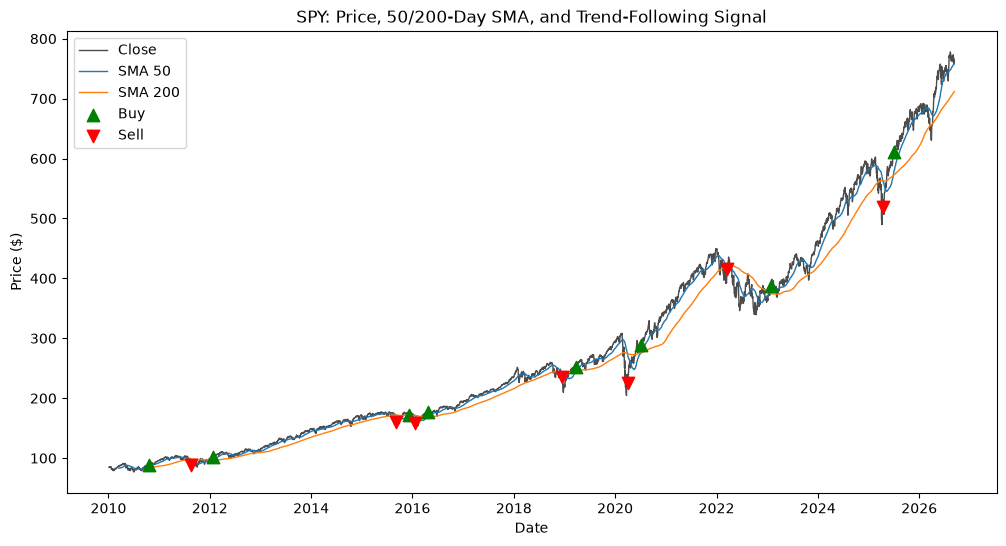

In [5]:
spy = sig[sig["Ticker"] == "SPY"].copy()
spy["PositionChange"] = spy["Position"].diff()

buys = spy[spy["PositionChange"] == 1]
sells = spy[spy["PositionChange"] == -1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(spy["Date"], spy["Close"], label="Close", color="black", linewidth=1, alpha=0.7)
ax.plot(spy["Date"], spy["SMA_50"], label="SMA 50", linewidth=1)
ax.plot(spy["Date"], spy["SMA_200"], label="SMA 200", linewidth=1)
ax.scatter(buys["Date"], buys["Close"], marker="^", color="green", s=80, label="Buy", zorder=5)
ax.scatter(sells["Date"], sells["Close"], marker="v", color="red", s=80, label="Sell", zorder=5)

ax.set_title("SPY: Price, 50/200-Day SMA, and Trend-Following Signal")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


## Notes / Next Step

Buy markers line up with the 50-day SMA crossing above the 200-day SMA (and vice versa for sells), confirming the signal logic is correct. Trade counts are low (roughly one per year), consistent with a slow trend-following signal rather than active trading.

**Next:** `04_backtest.ipynb` -- apply `Position` to actual next-day returns to build a strategy equity curve, and compare it against buy-and-hold.
